# Quantitative Trading with Machine Learning
## Volkswagen Frankfurt — modular experiment

This notebook reproduces the earlier 60/40 chronological experiment with a 20-day return horizon. It compares Elastic Net, Ridge, and Extra Trees, and reports trading performance against buy-and-hold over the same sampled evaluation periods.

Run the eight code cells in order. The dataset is expected at `/content/databaseFrankfurtComplete.csv`.

## Cell 1 — Imports, configuration, and data loading

Load the Frankfurt dataset, parse dates, and validate the price and date columns.

In [1]:
# CELL 1 — Imports, configuration, and dataset loading

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

SEED = 42
DATA_PATH = "/content/databaseFrankfurtComplete.csv"
HORIZON = 20
TRANSACTION_COST = 0.001  # 0.1% per unit of position turnover
SPLIT_RATIO = 0.60

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. "
        "Make sure databaseFrankfurtComplete.csv is already in /content."
    )

df = pd.read_csv(DATA_PATH, low_memory=False)

required_cols = {"Date", "Close"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Dataset is missing required columns: {missing}")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)
df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
df = (
    df.dropna(subset=["Date", "Close"])
      .sort_values("Date")
      .drop_duplicates(subset=["Date"])
      .reset_index(drop=True)
)

print("Dataset loaded:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
display(df[["Date", "Close"]].head())

Dataset loaded: (3809, 1292)
Date range: 2005-01-03 00:00:00+00:00 to 2019-12-30 00:00:00+00:00


,Date,Close
0,2005-01-03 00:00:00+00:00,24.614100
1,2005-01-04 00:00:00+00:00,25.053894
2,2005-01-05 00:00:00+00:00,25.190874
3,2005-01-06 00:00:00+00:00,25.933481
4,2005-01-07 00:00:00+00:00,25.911858


## Cell 2 — Target and features

Build the 20-row forward return from closing prices. Use the available VW return lags, supplier daily-return features, and rolling momentum/volatility features.

In [2]:
# CELL 2 — Build target and features

close = df["Close"].astype(float)
daily = close.pct_change()

# Return from close(t) to close(t + 20 trading rows).
y = close.shift(-HORIZON) / close - 1.0

supplier = [
    c for c in df.columns
    if c.startswith("Return_Delta1_")
    and "Future" not in c
    and "future" not in c
]
vw_lags = [
    f"Return_Delta{k}_VW"
    for k in range(1, 29)
    if f"Return_Delta{k}_VW" in df.columns
]

feature_cols = list(dict.fromkeys(supplier + vw_lags))
X = df[feature_cols].copy()

for w in [5, 10, 20, 60]:
    X[f"momentum_{w}"] = close / close.shift(w) - 1.0
    X[f"volatility_{w}"] = daily.rolling(w).std()

X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.loc[:, X.notna().any() & (X.nunique(dropna=True) > 1)]

valid = y.notna()
print("Feature count:", X.shape[1])
print("Rows with valid targets:", int(valid.sum()))

Feature count: 66
Rows with valid targets: 3789


## Cell 3 — Chronological 60/40 split

The first 60% is used to fit the models; the remaining 40% is used for evaluation. The final 20 rows before the split are purged from fitting so their forward targets do not cross the boundary. Trading metrics use non-overlapping 20-row periods.

In [3]:
# CELL 3 — Create chronological split and evaluation periods

valid_idx = np.flatnonzero(valid.to_numpy())
split_at = int(len(valid_idx) * SPLIT_RATIO)

fit_idx = valid_idx[:split_at]
eval_idx = valid_idx[split_at:]

split_date = df.loc[eval_idx[0], "Date"]
purge_date = split_date - pd.Timedelta(days=HORIZON)

fit_dates = df.loc[fit_idx, "Date"]
fit_idx = fit_idx[(fit_dates < purge_date).to_numpy()]

fit_periods = fit_idx[fit_idx % HORIZON == 0]
eval_periods = eval_idx[eval_idx % HORIZON == 0]

if min(len(fit_idx), len(eval_idx), len(fit_periods), len(eval_periods)) == 0:
    raise ValueError("A split or sampled period is empty. Check the dataset.")

print("Fit rows:", len(fit_idx))
print("Evaluation rows:", len(eval_idx))
print("Fit trading periods:", len(fit_periods))
print("Evaluation trading periods:", len(eval_periods))
print("Fit dates:", df.loc[fit_idx[0], "Date"], "to", df.loc[fit_idx[-1], "Date"])
print("Evaluation dates:", df.loc[eval_idx[0], "Date"], "to", df.loc[eval_idx[-1], "Date"])

Fit rows: 2259
Evaluation rows: 1516
Fit trading periods: 113
Evaluation trading periods: 76
Fit dates: 2005-01-03 00:00:00+00:00 to 2013-11-13 00:00:00+00:00
Evaluation dates: 2013-12-04 00:00:00+00:00 to 2019-11-27 00:00:00+00:00


## Cell 4 — Fit the three models

Train Elastic Net, Ridge, and Extra Trees using the first segment. Training targets are clipped at the 1st and 99th percentiles to reduce the influence of extreme observations.

In [4]:
# CELL 4 — Define and fit models

lo, hi = y.iloc[fit_idx].quantile([0.01, 0.99])
y_fit = y.clip(lower=lo, upper=hi)

models = {
    "ElasticNet": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=10000, random_state=SEED)
    ),
    "Ridge": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        Ridge(alpha=10.0)
    ),
    "ExtraTrees": make_pipeline(
        SimpleImputer(strategy="median"),
        ExtraTreesRegressor(
            n_estimators=250,
            min_samples_leaf=15,
            max_features=0.7,
            n_jobs=-1,
            random_state=SEED
        )
    )
}

validation_models = {}
fit_predictions = {}
eval_predictions = {}

for name, model in models.items():
    model.fit(X.iloc[fit_idx], y_fit.iloc[fit_idx])
    validation_models[name] = model
    fit_predictions[name] = model.predict(X.iloc[fit_periods])
    eval_predictions[name] = model.predict(X.iloc[eval_periods])

print("Models fitted:", list(validation_models.keys()))

Models fitted: ['ElasticNet', 'Ridge', 'ExtraTrees']


## Cell 5 — Choose a trading threshold

For each model, evaluate thresholds and both long-only and long-short modes on the fitting-period predictions. Choose the configuration with the highest approximate annualized Sharpe ratio, then freeze it for the later evaluation segment.

In [5]:
# CELL 5 — Threshold selection on fitting-period predictions

fit_actual = y.iloc[fit_periods].to_numpy()
eval_actual = y.iloc[eval_periods].to_numpy()

def annualized_sharpe(returns):
    returns = np.asarray(returns, dtype=float)
    return (
        returns.mean() / (returns.std() + 1e-12)
        * np.sqrt(252 / HORIZON)
    )

def make_positions(predictions, threshold, mode):
    predictions = np.asarray(predictions)
    return np.where(
        predictions > threshold,
        1,
        np.where(
            (predictions < -threshold) & (mode == "long_short"),
            -1,
            0
        )
    )

def strategy_returns(positions, actual_returns, cost=TRANSACTION_COST):
    positions = np.asarray(positions, dtype=float)
    actual_returns = np.asarray(actual_returns, dtype=float)
    turnover = np.abs(np.diff(np.r_[0, positions]))
    return positions * actual_returns - cost * turnover

selected_configs = {}

for name, fit_pred in fit_predictions.items():
    thresholds = np.unique(
        np.quantile(np.abs(fit_pred), [0, 0.25, 0.50, 0.70])
    )
    best = None

    for threshold in thresholds:
        for mode in ["long_only", "long_short"]:
            positions = make_positions(fit_pred, threshold, mode)
            returns = strategy_returns(positions, fit_actual)
            sharpe = annualized_sharpe(returns)

            if best is None or sharpe > best[0]:
                best = (sharpe, float(threshold), mode)

    selected_configs[name] = {
        "fit_sharpe": best[0],
        "threshold": best[1],
        "mode": best[2]
    }

print(pd.DataFrame(selected_configs).T.round(5).to_string())

           fit_sharpe threshold        mode
ElasticNet   1.342932  0.000374  long_short
Ridge        1.240004  0.001517  long_short
ExtraTrees   2.124658  0.019634  long_short


## Cell 6 — Evaluate model and strategy metrics

Calculate prediction errors, directional accuracy, compounded strategy return, buy-and-hold return, approximate Sharpe ratios, drawdowns, and exposure. Buy-and-hold is evaluated over the same non-overlapping periods.

In [6]:
# CELL 6 — Calculate evaluation metrics

def total_return_pct(returns):
    return (np.prod(1 + np.asarray(returns)) - 1) * 100

def max_drawdown_pct(returns):
    equity = np.r_[1.0, np.cumprod(1 + np.asarray(returns))]
    peaks = np.maximum.accumulate(equity)
    return np.min(equity / peaks - 1) * 100

results = []

for name, pred in eval_predictions.items():
    actual = eval_actual
    cfg = selected_configs[name]

    positions = make_positions(pred, cfg["threshold"], cfg["mode"])
    net_returns = strategy_returns(positions, actual)
    buy_hold_returns = actual

    mae = mean_absolute_error(actual, pred)
    zero_mae = mean_absolute_error(actual, np.zeros_like(actual))

    results.append({
        "Model": name,
        "Features": X.shape[1],
        "Fit_Rows": len(fit_idx),
        "Evaluation_Rows": len(eval_idx),
        "Fit_Periods": len(fit_periods),
        "Evaluation_Periods": len(eval_periods),
        "Test_MAE": mae,
        "Zero_Baseline_MAE": zero_mae,
        "MAE_Improvement_Pct": (zero_mae - mae) / zero_mae * 100,
        "Directional_Accuracy_Pct": np.mean(np.sign(pred) == np.sign(actual)) * 100,
        "Selected_Threshold": cfg["threshold"],
        "Position_Mode": cfg["mode"],
        "Strategy_Return_Pct": total_return_pct(net_returns),
        "Buy_Hold_Return_Pct": total_return_pct(buy_hold_returns),
        "Strategy_Sharpe": annualized_sharpe(net_returns),
        "Buy_Hold_Sharpe": annualized_sharpe(buy_hold_returns),
        "Strategy_Max_Drawdown_Pct": max_drawdown_pct(net_returns),
        "Buy_Hold_Max_Drawdown_Pct": max_drawdown_pct(buy_hold_returns),
        "Invested_Pct": np.mean(positions != 0) * 100
    })

results_df = pd.DataFrame(results).sort_values(
    "Strategy_Sharpe", ascending=False
)
display(results_df.round(4))

,Model,Features,Fit_Rows,Evaluation_Rows,Fit_Periods,Evaluation_Periods,Test_MAE,Zero_Baseline_MAE,MAE_Improvement_Pct,Directional_Accuracy_Pct,Selected_Threshold,Position_Mode,Strategy_Return_Pct,Buy_Hold_Return_Pct,Strategy_Sharpe,Buy_Hold_Sharpe,Strategy_Max_Drawdown_Pct,Buy_Hold_Max_Drawdown_Pct,Invested_Pct
1,Ridge,66,2259,1516,113,76,0.0683,0.0671,-1.7874,53.9474,0.0015,long_short,81.7113,10.711,0.4999,0.2006,-38.1649,-48.239,98.6842
0,ElasticNet,66,2259,1516,113,76,0.0684,0.0671,-1.8728,51.3158,0.0004,long_short,43.4796,10.711,0.3566,0.2006,-41.9544,-48.239,98.6842
2,ExtraTrees,66,2259,1516,113,76,0.0737,0.0671,-9.7774,52.6316,0.0196,long_short,34.2865,10.711,0.3203,0.2006,-49.8878,-48.239,88.1579


## Cell 7 — Review the comparison

Use the table to identify the strongest strategy under this experiment's selected metric. Read prediction errors separately from trading returns: a higher return does not necessarily mean lower forecast error.

In [7]:
# CELL 7 — Focused comparison table

comparison_cols = [
    "Model",
    "Test_MAE",
    "Zero_Baseline_MAE",
    "MAE_Improvement_Pct",
    "Directional_Accuracy_Pct",
    "Strategy_Return_Pct",
    "Buy_Hold_Return_Pct",
    "Strategy_Sharpe",
    "Buy_Hold_Sharpe",
    "Strategy_Max_Drawdown_Pct",
    "Buy_Hold_Max_Drawdown_Pct",
    "Invested_Pct"
]

comparison = results_df[comparison_cols].copy()
display(comparison.round(4))

best_row = results_df.loc[results_df["Strategy_Sharpe"].idxmax()]
print("Highest evaluation Sharpe model:", best_row["Model"])
print(f"Strategy return: {best_row['Strategy_Return_Pct']:+.2f}%")
print(f"Buy-and-hold return: {best_row['Buy_Hold_Return_Pct']:+.2f}%")

,Model,Test_MAE,Zero_Baseline_MAE,MAE_Improvement_Pct,Directional_Accuracy_Pct,Strategy_Return_Pct,Buy_Hold_Return_Pct,Strategy_Sharpe,Buy_Hold_Sharpe,Strategy_Max_Drawdown_Pct,Buy_Hold_Max_Drawdown_Pct,Invested_Pct
1,Ridge,0.0683,0.0671,-1.7874,53.9474,81.7113,10.711,0.4999,0.2006,-38.1649,-48.239,98.6842
0,ElasticNet,0.0684,0.0671,-1.8728,51.3158,43.4796,10.711,0.3566,0.2006,-41.9544,-48.239,98.6842
2,ExtraTrees,0.0737,0.0671,-9.7774,52.6316,34.2865,10.711,0.3203,0.2006,-49.8878,-48.239,88.1579


Highest evaluation Sharpe model: Ridge
Strategy return: +81.71%
Buy-and-hold return: +10.71%


## Cell 8 — Presentation charts and CSV output

Create charts for return, Sharpe ratio, drawdown, and prediction error. Save the metrics as a CSV file. This cell does not create ZIP files.

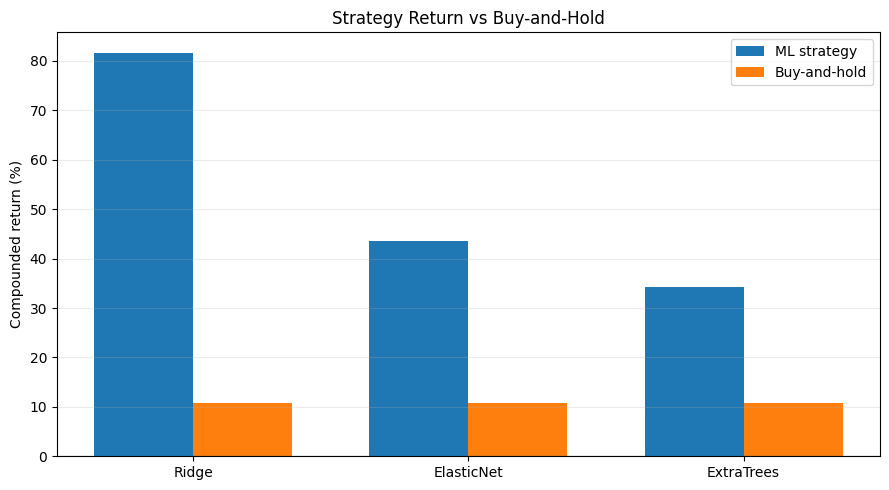

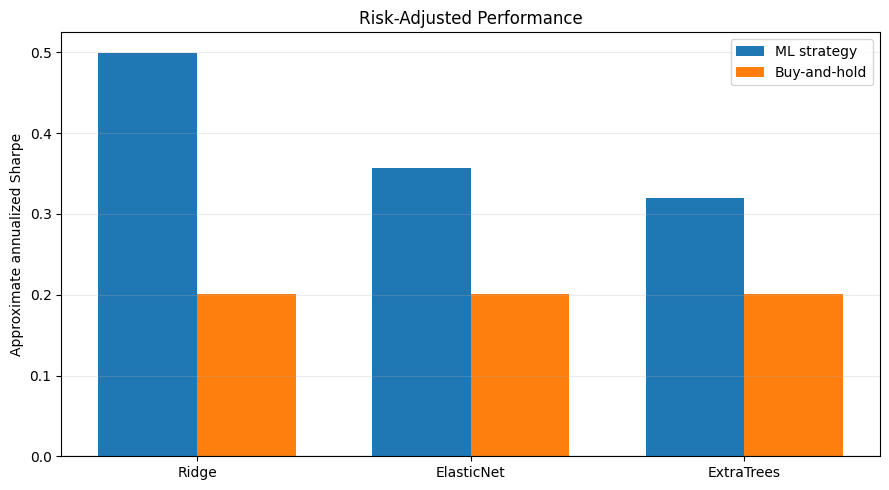

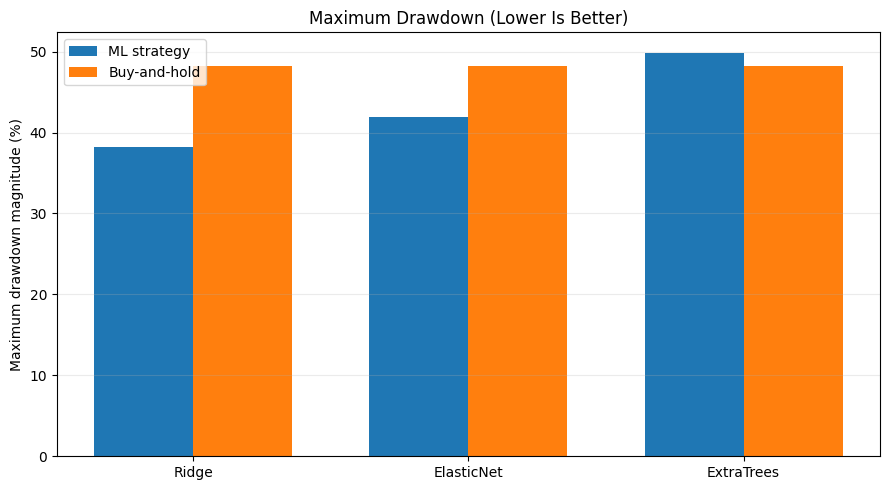

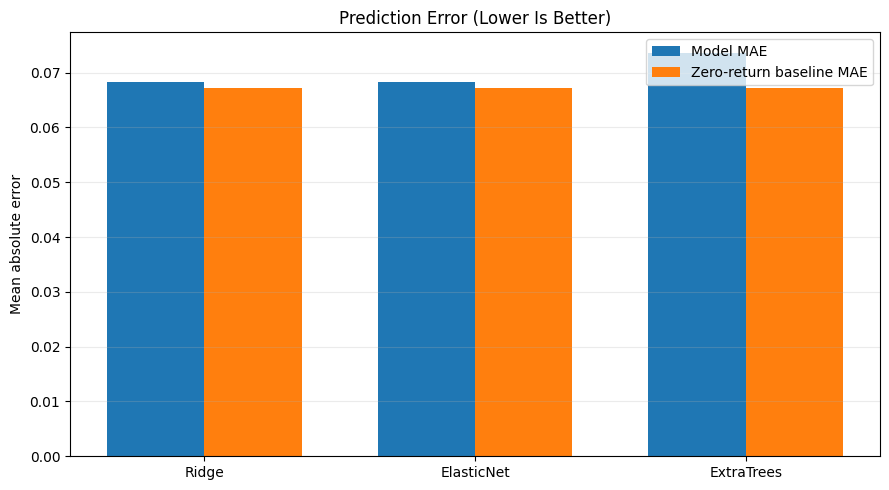

In [9]:
# CELL 8 — Charts and CSV export

plot_df = results_df.reset_index(drop=True)
x = np.arange(len(plot_df))
width = 0.36

# Chart 1: compounded return
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, plot_df["Strategy_Return_Pct"], width, label="ML strategy")
ax.bar(x + width/2, plot_df["Buy_Hold_Return_Pct"], width, label="Buy-and-hold")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"])
ax.set_ylabel("Compounded return (%)")
ax.set_title("Strategy Return vs Buy-and-Hold")
ax.axhline(0, linewidth=0.8)
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Chart 2: Sharpe ratio
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, plot_df["Strategy_Sharpe"], width, label="ML strategy")
ax.bar(x + width/2, plot_df["Buy_Hold_Sharpe"], width, label="Buy-and-hold")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"])
ax.set_ylabel("Approximate annualized Sharpe")
ax.set_title("Risk-Adjusted Performance")
ax.axhline(0, linewidth=0.8)
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Chart 3: drawdown magnitude
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, plot_df["Strategy_Max_Drawdown_Pct"].abs(),
       width, label="ML strategy")
ax.bar(x + width/2, plot_df["Buy_Hold_Max_Drawdown_Pct"].abs(),
       width, label="Buy-and-hold")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"])
ax.set_ylabel("Maximum drawdown magnitude (%)")
ax.set_title("Maximum Drawdown (Lower Is Better)")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Chart 4: prediction MAE
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, plot_df["Test_MAE"], width, label="Model MAE")
ax.bar(x + width/2, plot_df["Zero_Baseline_MAE"], width,
       label="Zero-return baseline MAE")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"])
ax.set_ylabel("Mean absolute error")
ax.set_title("Prediction Error (Lower Is Better)")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()